The Markdown Cell

# Data Analysis Template
### Project: [Project Name]
### Date: [Date]
### Dataset: [Dataset Name]

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import pandas as pd
df = pd.read_csv("FIFA17_official_data.csv")
print(df.head)
print(df.shape)

<bound method NDFrame.head of            ID            Name  Age  \
0      176580       L. Suárez   29   
1      178518   R. Nainggolan   28   
2      181872        A. Vidal   29   
3      197445        D. Alaba   24   
4      195864        P. Pogba   23   
...       ...             ...  ...   
17555  233215        C. Addai   18   
17556  232911     R. Kamiyama   31   
17557  235387         B. Gaye   18   
17558  237904   K. Olifirenko   18   
17559  237463       A. Kelsey   16   

                                                  Photo Nationality  \
0      https://cdn.sofifa.com/players/176/580/17_60.png     Uruguay   
1      https://cdn.sofifa.com/players/178/518/17_60.png     Belgium   
2      https://cdn.sofifa.com/players/181/872/17_60.png       Chile   
3      https://cdn.sofifa.com/players/197/445/17_60.png     Austria   
4      https://cdn.sofifa.com/players/195/864/17_60.png      France   
...                                                 ...         ...   
17555  https://c

In [3]:
print(df.head())
print("----")
print(df.info())
print("----")
print(df.describe())

       ID            Name  Age  \
0  176580       L. Suárez   29   
1  178518   R. Nainggolan   28   
2  181872        A. Vidal   29   
3  197445        D. Alaba   24   
4  195864        P. Pogba   23   

                                              Photo Nationality  \
0  https://cdn.sofifa.com/players/176/580/17_60.png     Uruguay   
1  https://cdn.sofifa.com/players/178/518/17_60.png     Belgium   
2  https://cdn.sofifa.com/players/181/872/17_60.png       Chile   
3  https://cdn.sofifa.com/players/197/445/17_60.png     Austria   
4  https://cdn.sofifa.com/players/195/864/17_60.png      France   

                                  Flag  Overall  Potential               Club  \
0  https://cdn.sofifa.com/flags/uy.png       92         92       FC Barcelona   
1  https://cdn.sofifa.com/flags/be.png       86         86               Roma   
2  https://cdn.sofifa.com/flags/cl.png       87         87  FC Bayern München   
3  https://cdn.sofifa.com/flags/at.png       86         89  FC Bayer

In [4]:
print(df.isnull().sum())

ID                     0
Name                   0
Age                    0
Photo                  0
Nationality            0
                      ..
GKKicking              0
GKPositioning          0
GKReflexes             0
Best Position          0
Best Overall Rating    0
Length: 63, dtype: int64


In [6]:
# Remove € symbol and K notation from Wage
df["Wage"] = df["Wage"].str.replace("€", "")
df["Wage"] = df["Wage"].str.replace("K", "")
df["Wage"] = pd.to_numeric(df["Wage"], errors="coerce")
df["Wage"] = df["Wage"] * 1000

# Same for Value column
df["Value"] = df["Value"].str.replace("€", "")
df["Value"] = df["Value"].str.replace("K", "")
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
df["Value"] = df["Value"] * 1000

print("Cleaning complete!")
print(df[["Name", "Wage", "Value"]].head(10))

Cleaning complete!
                 Name    Wage  Value
0           L. Suárez  525000    NaN
1       R. Nainggolan  130000    NaN
2            A. Vidal  180000    NaN
3            D. Alaba  140000    NaN
4            P. Pogba  225000    NaN
5             G. Bale  375000    NaN
6         A. Florenzi   70000    NaN
7           L. Baines  100000    NaN
8           L. Modrić  325000    NaN
9   Cristiano Ronaldo  575000    NaN


In [8]:
# Average rating by Nationality
nationality = df.groupby("Nationality")["Overall"].mean().nlargest(10)
print(nationality)

#Top 10 highest rated players
top10 = df.nlargest(10, "Overall")[["Name", "Club", "Overall", "Nationality"]]
print(top10)

#Top spending clubs by wage bill
club_wages = df.groupby("Club")["Wage"].sum().nlargest(10)
print(club_wages)

Nationality
Chad                   74.000000
São Tomé & Príncipe    74.000000
Dominican Republic     73.500000
Cuba                   72.000000
Guatemala              72.000000
Oman                   72.000000
Algeria                71.411765
Ecuador                71.258065
Czech Republic         71.125000
Eritrea                71.000000
Name: Overall, dtype: float64
                     Name               Club  Overall Nationality
9       Cristiano Ronaldo        Real Madrid       94    Portugal
58               L. Messi       FC Barcelona       93   Argentina
0               L. Suárez       FC Barcelona       92     Uruguay
168                Neymar       FC Barcelona       92      Brazil
12372            M. Neuer  FC Bayern München       92     Germany
5                 G. Bale        Real Madrid       90       Wales
109        R. Lewandowski  FC Bayern München       90      Poland
118        Z. Ibrahimović  Manchester United       90      Sweden
13739              De Gea  Manches

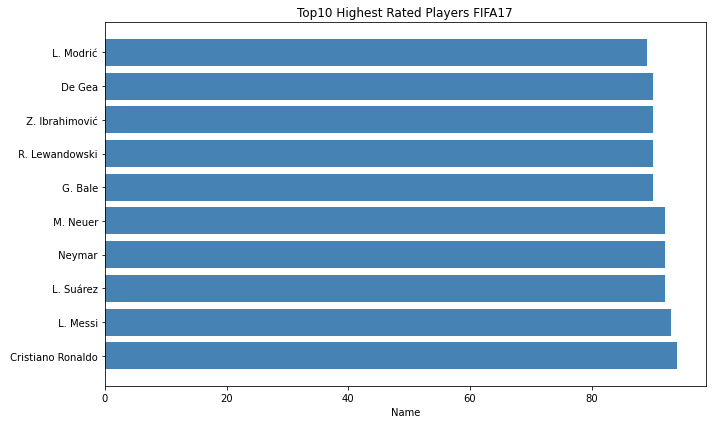

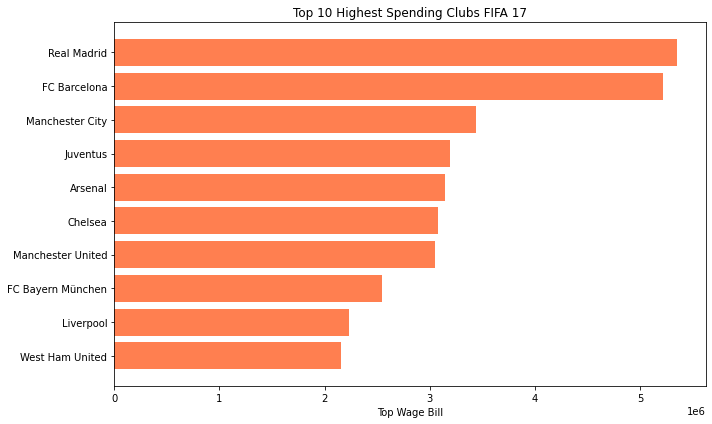

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("FIFA17_official_data.csv")

top10 = df.nlargest(10, "Overall")
plt.figure(figsize=(10, 6))
plt.barh(top10["Name"], top10["Overall"], color=["steelblue"])
plt.title("Top10 Highest Rated Players FIFA17")
plt.xlabel("Name")
plt.tight_layout()
plt.savefig("top10_players.png", dpi=150)
plt.show()  

def parse_wage(val):
    val = str(val).replace("€", "").strip()
    if "K" in val:
        return float(val.replace("K", "")) * 1000
    elif "M" in val:
        return float(val.replace("M", "")) * 1000000
    else:
        return float(val) if val.isdigit() else 0

df["Wage"] = df["Wage"].apply(parse_wage)


#Top 10 clubs by wage bill
club_wages = df.groupby("Club")["Wage"].sum().nlargest(10)

plt.figure(figsize=(10, 6))
plt.barh(club_wages.index, club_wages.values, color="coral")
plt.xlabel("Top Wage Bill")
plt.title("Top 10 Highest Spending Clubs FIFA 17")
plt.gca().invert_yaxis()
plt.tight_layout()                    
plt.savefig("top_clubs_wage.png", dpi=150)
plt.show()                    
                    
                    
                    

In [2]:
# Save cleaned data
df.to_csv("FIFA17_official_data.csv", index=False)
print("Export complete!")

Export complete!
